In [2]:
"""
TASK 1: FERTILE SITE RECOMMENDATION - OPTION 2 IMPROVED
Target: Composite Fertility Index (Regression Only)
Models: Random Forest + XGBoost with TimeSeriesSplit Cross-Validation

Improvements:
1. Removed classification (due to class imbalance)
2. Added XGBoost for comparison
3. Added TimeSeriesSplit cross-validation (respects temporal order)
4. More robust evaluation

NO DATA LEAKAGE - All FI components removed from features
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score, KFold, TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Check if XGBoost is available
try:
    import xgboost as xgb
    XGBOOST_AVAILABLE = True
    print("✓ XGBoost is available")
except Exception as e:
    XGBOOST_AVAILABLE = False
    print("⚠️  XGBoost not available")
    if "OpenMP" in str(e) or "libomp" in str(e):
        print("   Reason: OpenMP library missing - run: brew install libomp")
    else:
        print(f"   Reason: {str(e)[:100]}")
    print("   Continuing with Random Forest only...")

print("="*80)
print("TASK 1: FERTILE SITE RECOMMENDATION - OPTION 2 IMPROVED")
print("TARGET: Composite Fertility Index (Regression Only)")
print("="*80)

# ==============================================================================
# STEP 1: LOAD DATA
# ==============================================================================
print("\n1. LOADING DATA")
print("-" * 60)

df_original = pd.read_csv('csv/Bangalore_Monthly_Final_Corrected.csv')
print(f"Original data shape: {df_original.shape}")

X_train = pd.read_csv('csv/X_train.csv')
X_val = pd.read_csv('csv/X_val.csv')
X_test = pd.read_csv('csv/X_test.csv')

print(f"\nPreprocessed features loaded:")
print(f"  X_train: {X_train.shape}")
print(f"  X_val: {X_val.shape}")
print(f"  X_test: {X_test.shape}")

✓ XGBoost is available
TASK 1: FERTILE SITE RECOMMENDATION - OPTION 2 IMPROVED
TARGET: Composite Fertility Index (Regression Only)

1. LOADING DATA
------------------------------------------------------------
Original data shape: (23042, 26)

Preprocessed features loaded:
  X_train: (11397, 19)
  X_val: (3397, 19)
  X_test: (8248, 19)


In [3]:
# ==============================================================================
# STEP 2: CREATE COMPOSITE FERTILITY INDEX
# ==============================================================================
print("\n2. CREATING COMPOSITE FERTILITY INDEX")
print("-" * 60)

df_original['date'] = pd.to_datetime(df_original['date'])
df_original['Year'] = df_original['date'].dt.year
df_original['Month_Actual'] = df_original['date'].dt.month

import json
def extract_coordinates(geo_str):
    try:
        geo_dict = json.loads(geo_str)
        coords = geo_dict['coordinates']
        return coords[0], coords[1]
    except:
        return None, None

df_original['longitude'], df_original['latitude'] = zip(
    *df_original['.geo'].apply(extract_coordinates)
)

df_sorted = df_original.sort_values(['date', 'longitude', 'latitude']).reset_index(drop=True)

# Research-based weights
WEIGHTS = {
    'Nitrogen': 0.40,
    'pH': 0.25,
    'NDVI': 0.15,
    'SoilMoisture': 0.10,
    'Clay': 0.10
}

print(f"\nResearch-Based Weights:")
for comp, weight in WEIGHTS.items():
    print(f"  {comp:15s}: {weight:.2f}")

# Normalization functions
def normalize_minmax(values):
    scaler = MinMaxScaler()
    return scaler.fit_transform(values.values.reshape(-1, 1)).flatten()

def normalize_ph_optimal(ph_values, optimal=6.5, tolerance=1.0):
    deviation = np.abs(ph_values - optimal)
    scores = 1 - (deviation / tolerance)
    return np.clip(scores, 0, 1)

# Create normalized scores
df_sorted['N_score'] = normalize_minmax(df_sorted['Nitrogen'])
df_sorted['pH_score'] = normalize_ph_optimal(df_sorted['pH'])
df_sorted['NDVI_score'] = normalize_minmax(df_sorted['NDVI'])
df_sorted['Moisture_score'] = normalize_minmax(df_sorted['SoilMoisture'])
df_sorted['Clay_score'] = normalize_minmax(df_sorted['Clay'])

# Calculate Composite Fertility Index
df_sorted['FertilityIndex'] = (
    WEIGHTS['Nitrogen'] * df_sorted['N_score'] +
    WEIGHTS['pH'] * df_sorted['pH_score'] +
    WEIGHTS['NDVI'] * df_sorted['NDVI_score'] +
    WEIGHTS['SoilMoisture'] * df_sorted['Moisture_score'] +
    WEIGHTS['Clay'] * df_sorted['Clay_score']
)

print(f"\n✓ Fertility Index created")
print(f"  Range: [{df_sorted['FertilityIndex'].min():.3f}, {df_sorted['FertilityIndex'].max():.3f}]")
print(f"  Mean: {df_sorted['FertilityIndex'].mean():.3f} ± {df_sorted['FertilityIndex'].std():.3f}")
print(f"  Median: {df_sorted['FertilityIndex'].median():.3f}")
print(f"  25th percentile: {df_sorted['FertilityIndex'].quantile(0.25):.3f}")
print(f"  75th percentile: {df_sorted['FertilityIndex'].quantile(0.75):.3f}")


2. CREATING COMPOSITE FERTILITY INDEX
------------------------------------------------------------

Research-Based Weights:
  Nitrogen       : 0.40
  pH             : 0.25
  NDVI           : 0.15
  SoilMoisture   : 0.10
  Clay           : 0.10

✓ Fertility Index created
  Range: [0.266, 0.842]
  Mean: 0.418 ± 0.058
  Median: 0.411
  25th percentile: 0.381
  75th percentile: 0.446


In [4]:
# ==============================================================================
# STEP 3: EXTRACT TARGETS
# ==============================================================================
print("\n3. EXTRACTING TARGETS")
print("-" * 60)

train_mask = ((df_sorted['Year'] == 2021) | 
              ((df_sorted['Year'] == 2022) & (df_sorted['Month_Actual'] <= 6)))
val_mask = ((df_sorted['Year'] == 2022) & (df_sorted['Month_Actual'] >= 7))
test_mask = df_sorted['Year'] == 2023

y_train = df_sorted.loc[train_mask, 'FertilityIndex'].values
y_val = df_sorted.loc[val_mask, 'FertilityIndex'].values
y_test = df_sorted.loc[test_mask, 'FertilityIndex'].values

print(f"Target statistics:")
print(f"  Train: {len(y_train)} samples, FI range [{y_train.min():.3f}, {y_train.max():.3f}]")
print(f"  Val:   {len(y_val)} samples, FI range [{y_val.min():.3f}, {y_val.max():.3f}]")
print(f"  Test:  {len(y_test)} samples, FI range [{y_test.min():.3f}, {y_test.max():.3f}]")


3. EXTRACTING TARGETS
------------------------------------------------------------
Target statistics:
  Train: 11397 samples, FI range [0.266, 0.842]
  Val:   3397 samples, FI range [0.349, 0.814]
  Test:  8248 samples, FI range [0.274, 0.816]


In [5]:
# ==============================================================================
# STEP 4: REMOVE ALL FI COMPONENTS FROM FEATURES
# ==============================================================================
print("\n4. REMOVING ALL FI COMPONENTS FROM FEATURES")
print("-" * 60)

components_to_remove = ['Nitrogen_log', 'pH', 'NDVI', 'SoilMoisture', 'Clay']

features_to_keep = [
    'Rain_log', 'Temp', 'LST',
    'green_fraction_boxcox',
    'BulkDensity',
    'Elevation', 'Slope_log',
    'AOD_log', 'NO2_log', 'SO2',
    'Month_Sin', 'Month_Cos',
    'longitude', 'latitude'
]

print(f"Original features: {X_train.shape[1]}")
print(f"Components removed: {len(components_to_remove)}")
print(f"  - {', '.join(components_to_remove)}")
print(f"Final features: {len(features_to_keep)}")

for comp in components_to_remove:
    if comp in features_to_keep:
        raise ValueError(f"ERROR: {comp} still in features!")

print("✓ Confirmed: ALL FI components removed - NO DATA LEAKAGE")

X_train_clean = X_train[features_to_keep].copy()
X_val_clean = X_val[features_to_keep].copy()
X_test_clean = X_test[features_to_keep].copy()

print(f"\nFinal feature sets:")
print(f"  X_train: {X_train_clean.shape}")
print(f"  X_val: {X_val_clean.shape}")
print(f"  X_test: {X_test_clean.shape}")


4. REMOVING ALL FI COMPONENTS FROM FEATURES
------------------------------------------------------------
Original features: 19
Components removed: 5
  - Nitrogen_log, pH, NDVI, SoilMoisture, Clay
Final features: 14
✓ Confirmed: ALL FI components removed - NO DATA LEAKAGE

Final feature sets:
  X_train: (11397, 14)
  X_val: (3397, 14)
  X_test: (8248, 14)


In [6]:
# ==============================================================================
# STEP 5: TRAIN RANDOM FOREST WITH CROSS-VALIDATION
# ==============================================================================
print("\n5. TRAINING RANDOM FOREST WITH CROSS-VALIDATION")
print("-" * 60)

rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=20,
    min_samples_split=10,
    min_samples_leaf=4,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)

print("Random Forest hyperparameters:")
print(f"  n_estimators: {rf_model.n_estimators}")
print(f"  max_depth: {rf_model.max_depth}")
print(f"  min_samples_split: {rf_model.min_samples_split}")

# Cross-validation on training set
print("\n📊 TimeSeriesSplit Cross-Validation (5 Splits):")
print("   Uses expanding window to respect temporal order")
print("   Each split trains on progressively more data, tests on next period")
tscv = TimeSeriesSplit(n_splits=5)

cv_scores_r2 = cross_val_score(rf_model, X_train_clean, y_train, 
                                cv=tscv, scoring='r2', n_jobs=-1)
cv_scores_mae = -cross_val_score(rf_model, X_train_clean, y_train, 
                                  cv=tscv, scoring='neg_mean_absolute_error', n_jobs=-1)
cv_scores_rmse = np.sqrt(-cross_val_score(rf_model, X_train_clean, y_train, 
                                           cv=tscv, scoring='neg_mean_squared_error', n_jobs=-1))

print(f"  R² scores:   {cv_scores_r2}")
print(f"  Mean R²:     {cv_scores_r2.mean():.4f} ± {cv_scores_r2.std():.4f}")
print(f"  MAE scores:  {cv_scores_mae}")
print(f"  Mean MAE:    {cv_scores_mae.mean():.4f} ± {cv_scores_mae.std():.4f}")
print(f"  Mean RMSE:   {cv_scores_rmse.mean():.4f} ± {cv_scores_rmse.std():.4f}")

# Train on full training set
print("\nTraining on full training set...")
rf_model.fit(X_train_clean, y_train)
print("✓ Random Forest trained!")

# Predictions
y_train_pred_rf = rf_model.predict(X_train_clean)
y_val_pred_rf = rf_model.predict(X_val_clean)
y_test_pred_rf = rf_model.predict(X_test_clean)

# Metrics
def calculate_metrics(y_true, y_pred, model_name, set_name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-10))) * 100
    
    print(f"\n{model_name} - {set_name} Set:")
    print(f"  MAE:  {mae:.4f}")
    print(f"  RMSE: {rmse:.4f}")
    print(f"  R²:   {r2:.4f}")
    print(f"  MAPE: {mape:.2f}%")
    
    return {'MAE': mae, 'RMSE': rmse, 'R2': r2, 'MAPE': mape}

rf_metrics_train = calculate_metrics(y_train, y_train_pred_rf, "Random Forest", "Training")
rf_metrics_val = calculate_metrics(y_val, y_val_pred_rf, "Random Forest", "Validation")
rf_metrics_test = calculate_metrics(y_test, y_test_pred_rf, "Random Forest", "Test")


5. TRAINING RANDOM FOREST WITH CROSS-VALIDATION
------------------------------------------------------------
Random Forest hyperparameters:
  n_estimators: 200
  max_depth: 20
  min_samples_split: 10

📊 TimeSeriesSplit Cross-Validation (5 Splits):
   Uses expanding window to respect temporal order
   Each split trains on progressively more data, tests on next period
  R² scores:   [0.54866553 0.70103006 0.69569578 0.74685273 0.77351572]
  Mean R²:     0.6932 ± 0.0778
  MAE scores:  [0.02807687 0.02277174 0.02569588 0.0219154  0.02077071]
  Mean MAE:    0.0238 ± 0.0027
  Mean RMSE:   0.0307 ± 0.0042

Training on full training set...
✓ Random Forest trained!

Random Forest - Training Set:
  MAE:  0.0130
  RMSE: 0.0170
  R²:   0.9157
  MAPE: 3.11%

Random Forest - Validation Set:
  MAE:  0.0248
  RMSE: 0.0316
  R²:   0.6324
  MAPE: 5.37%

Random Forest - Test Set:
  MAE:  0.0230
  RMSE: 0.0296
  R²:   0.7103
  MAPE: 5.91%


In [7]:
# ==============================================================================
# STEP 6: TRAIN XGBOOST (if available)
# ==============================================================================
if XGBOOST_AVAILABLE:
    print("\n6. TRAINING XGBOOST WITH CROSS-VALIDATION")
    print("-" * 60)
    
    xgb_model = xgb.XGBRegressor(
        n_estimators=200,
        max_depth=8,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
        tree_method='hist'  # Faster training
    )
    
    print("XGBoost hyperparameters:")
    print(f"  n_estimators: {xgb_model.n_estimators}")
    print(f"  max_depth: {xgb_model.max_depth}")
    print(f"  learning_rate: {xgb_model.learning_rate}")
    
    # Cross-validation
    print("\n📊 TimeSeriesSplit Cross-Validation (5 Splits):")
    
    cv_scores_r2_xgb = cross_val_score(xgb_model, X_train_clean, y_train, 
                                       cv=tscv, scoring='r2', n_jobs=-1)
    cv_scores_mae_xgb = -cross_val_score(xgb_model, X_train_clean, y_train, 
                                         cv=tscv, scoring='neg_mean_absolute_error', n_jobs=-1)
    cv_scores_rmse_xgb = np.sqrt(-cross_val_score(xgb_model, X_train_clean, y_train, 
                                                   cv=tscv, scoring='neg_mean_squared_error', n_jobs=-1))
    
    print(f"  R² scores:   {cv_scores_r2_xgb}")
    print(f"  Mean R²:     {cv_scores_r2_xgb.mean():.4f} ± {cv_scores_r2_xgb.std():.4f}")
    print(f"  MAE scores:  {cv_scores_mae_xgb}")
    print(f"  Mean MAE:    {cv_scores_mae_xgb.mean():.4f} ± {cv_scores_mae_xgb.std():.4f}")
    print(f"  Mean RMSE:   {cv_scores_rmse_xgb.mean():.4f} ± {cv_scores_rmse_xgb.std():.4f}")
    
    # Train on full training set
    print("\nTraining on full training set...")
    xgb_model.fit(X_train_clean, y_train)
    print("✓ XGBoost trained!")
    
    # Predictions
    y_train_pred_xgb = xgb_model.predict(X_train_clean)
    y_val_pred_xgb = xgb_model.predict(X_val_clean)
    y_test_pred_xgb = xgb_model.predict(X_test_clean)
    
    # Metrics
    xgb_metrics_train = calculate_metrics(y_train, y_train_pred_xgb, "XGBoost", "Training")
    xgb_metrics_val = calculate_metrics(y_val, y_val_pred_xgb, "XGBoost", "Validation")
    xgb_metrics_test = calculate_metrics(y_test, y_test_pred_xgb, "XGBoost", "Test")


6. TRAINING XGBOOST WITH CROSS-VALIDATION
------------------------------------------------------------
XGBoost hyperparameters:
  n_estimators: 200
  max_depth: 8
  learning_rate: 0.1

📊 TimeSeriesSplit Cross-Validation (5 Splits):
  R² scores:   [0.75928485 0.85080136 0.84190264 0.92362447 0.94927191]
  Mean R²:     0.8650 ± 0.0670
  MAE scores:  [0.02195314 0.01654039 0.01918132 0.01254946 0.00992997]
  Mean MAE:    0.0160 ± 0.0043
  Mean RMSE:   0.0199 ± 0.0055

Training on full training set...
✓ XGBoost trained!

XGBoost - Training Set:
  MAE:  0.0032
  RMSE: 0.0042
  R²:   0.9949
  MAPE: 0.77%

XGBoost - Validation Set:
  MAE:  0.0170
  RMSE: 0.0206
  R²:   0.8444
  MAPE: 3.72%

XGBoost - Test Set:
  MAE:  0.0128
  RMSE: 0.0176
  R²:   0.8971
  MAPE: 3.31%


In [8]:
# ==============================================================================
# STEP 7: MODEL COMPARISON
# ==============================================================================
print("\n7. MODEL COMPARISON")
print("-" * 60)

print("\n📊 VALIDATION SET COMPARISON:")
print(f"{'Metric':<10} {'Random Forest':<15} {'XGBoost':<15} {'Winner':<15}")
print("-" * 60)

if XGBOOST_AVAILABLE:
    metrics_to_compare = ['R2', 'MAE', 'RMSE', 'MAPE']
    winners = []
    
    for metric in metrics_to_compare:
        rf_val = rf_metrics_val[metric]
        xgb_val = xgb_metrics_val[metric]
        
        if metric == 'R2':
            winner = 'RF' if rf_val > xgb_val else 'XGB'
        else:
            winner = 'RF' if rf_val < xgb_val else 'XGB'
        
        winners.append(winner)
        print(f"{metric:<10} {rf_val:<15.4f} {xgb_val:<15.4f} {winner:<15}")
    
    best_model = 'Random Forest' if winners.count('RF') >= 2 else 'XGBoost'
    print(f"\n✓ Best model (Validation): {best_model}")
else:
    print("Only Random Forest evaluated (XGBoost not available)")
    best_model = 'Random Forest'


7. MODEL COMPARISON
------------------------------------------------------------

📊 VALIDATION SET COMPARISON:
Metric     Random Forest   XGBoost         Winner         
------------------------------------------------------------
R2         0.6324          0.8444          XGB            
MAE        0.0248          0.0170          XGB            
RMSE       0.0316          0.0206          XGB            
MAPE       5.3702          3.7150          XGB            

✓ Best model (Validation): XGBoost


In [9]:
# ==============================================================================
# STEP 8: FEATURE IMPORTANCE ANALYSIS
# ==============================================================================
print("\n8. FEATURE IMPORTANCE ANALYSIS")
print("-" * 60)

feature_importance_df = pd.DataFrame({
    'Feature': features_to_keep,
    'RF_Importance': rf_model.feature_importances_
})

if XGBOOST_AVAILABLE:
    feature_importance_df['XGB_Importance'] = xgb_model.feature_importances_
    feature_importance_df = feature_importance_df.sort_values('RF_Importance', ascending=False)
    
    print("\nTop 10 Features:")
    print(feature_importance_df.head(10).to_string(index=False))
    
    # Correlation between RF and XGB feature importances
    corr = np.corrcoef(feature_importance_df['RF_Importance'], 
                       feature_importance_df['XGB_Importance'])[0, 1]
    print(f"\n✓ Feature importance correlation (RF vs XGB): {corr:.3f}")
else:
    feature_importance_df = feature_importance_df.sort_values('RF_Importance', ascending=False)
    print("\nTop 10 Features (Random Forest):")
    print(feature_importance_df[['Feature', 'RF_Importance']].head(10).to_string(index=False))


8. FEATURE IMPORTANCE ANALYSIS
------------------------------------------------------------

Top 10 Features:
              Feature  RF_Importance  XGB_Importance
          BulkDensity       0.281558        0.395564
             latitude       0.170381        0.165217
green_fraction_boxcox       0.110691        0.064006
                  LST       0.084587        0.081988
            Slope_log       0.069081        0.053344
            longitude       0.064470        0.058888
            Elevation       0.048549        0.035506
                 Temp       0.041038        0.012246
            Month_Cos       0.025668        0.084806
             Rain_log       0.024802        0.006097

✓ Feature importance correlation (RF vs XGB): 0.950



9. CREATING VISUALIZATIONS
------------------------------------------------------------
✓ Saved: Option2_Improved_Results.png


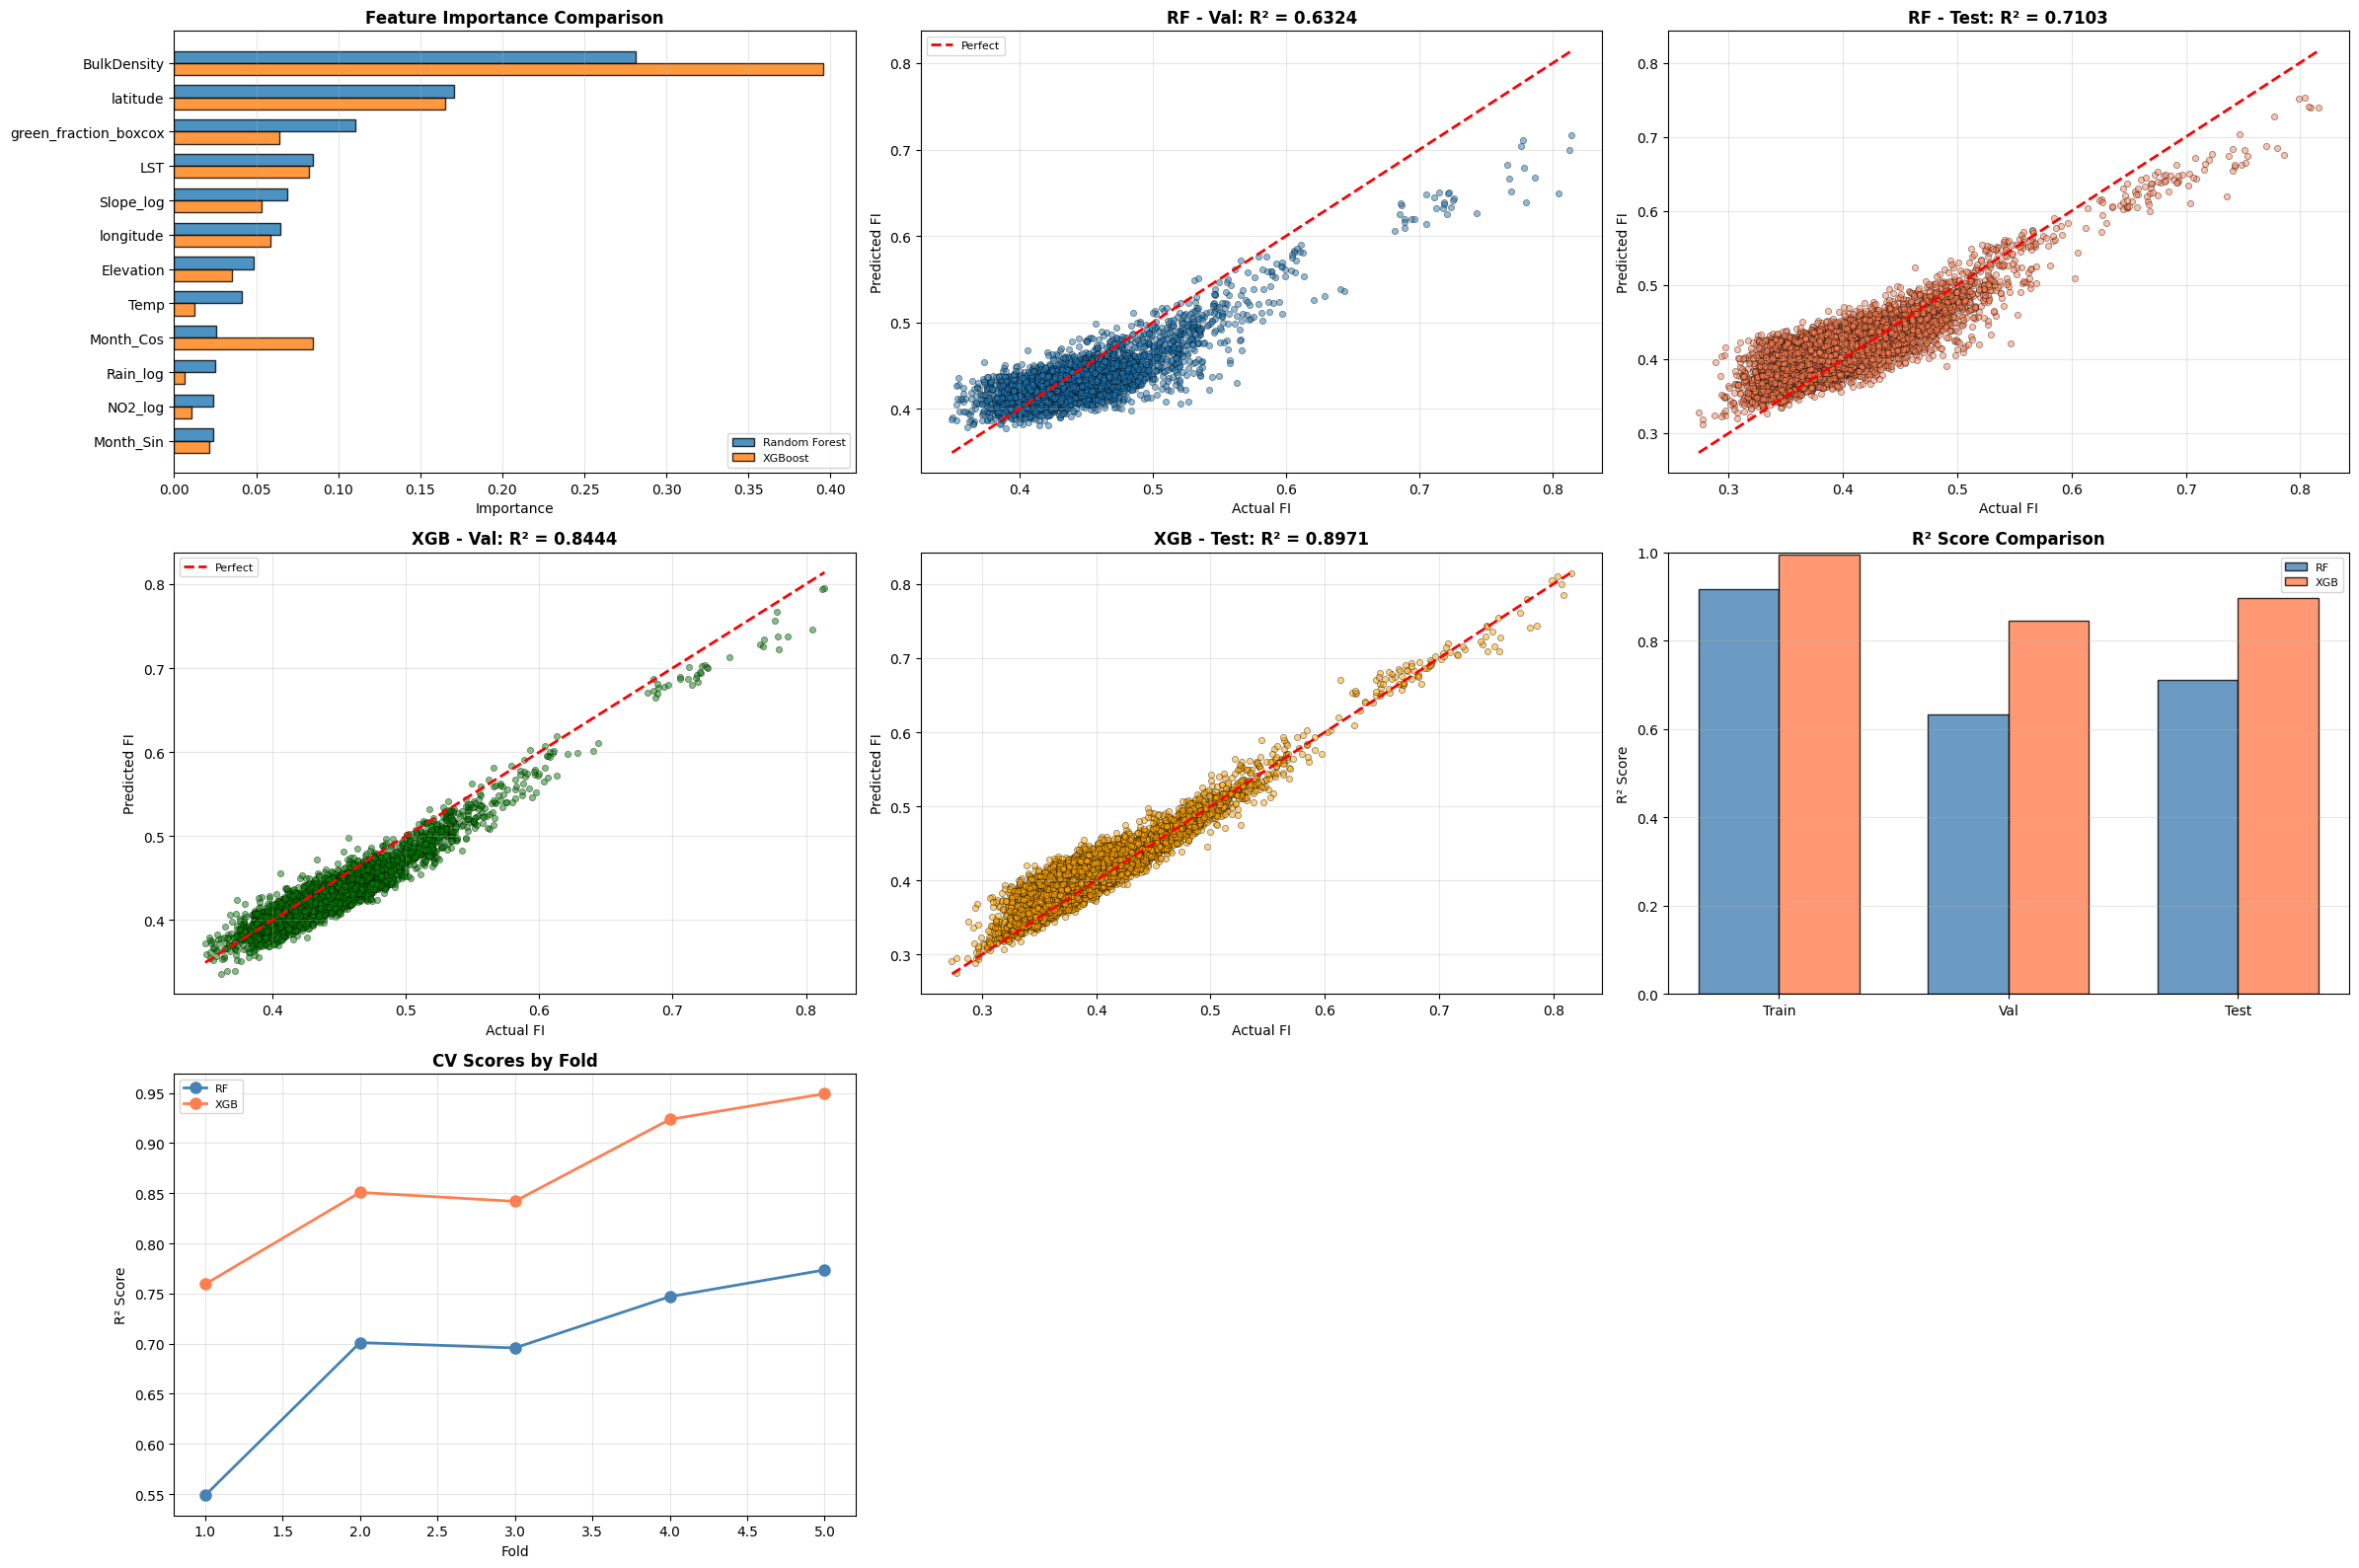

In [10]:
# ==============================================================================
# STEP 9: VISUALIZATIONS
# ==============================================================================
print("\n9. CREATING VISUALIZATIONS")
print("-" * 60)

if XGBOOST_AVAILABLE:
    fig = plt.figure(figsize=(24, 16))
    n_cols = 3
    n_rows = 3
else:
    fig = plt.figure(figsize=(20, 12))
    n_cols = 4
    n_rows = 3

plot_idx = 1

# 1. Feature Importance Comparison
ax1 = plt.subplot(n_rows, n_cols, plot_idx)
plot_idx += 1
top_n = 12
fi_top = feature_importance_df.head(top_n)
x = np.arange(top_n)
width = 0.35

plt.barh(x, fi_top['RF_Importance'], width, label='Random Forest', alpha=0.8, edgecolor='black')
if XGBOOST_AVAILABLE:
    plt.barh(x + width, fi_top['XGB_Importance'], width, label='XGBoost', alpha=0.8, edgecolor='black')
plt.yticks(x + width/2 if XGBOOST_AVAILABLE else x, fi_top['Feature'])
plt.xlabel('Importance', fontsize=10)
plt.title('Feature Importance Comparison', fontsize=12, fontweight='bold')
plt.legend(fontsize=8)
plt.gca().invert_yaxis()
plt.grid(alpha=0.3, axis='x')

# 2. Cross-Validation R² Scores
# ax2 = plt.subplot(n_rows, n_cols, plot_idx)
# plot_idx += 1
# cv_data = [cv_scores_r2]
# labels = ['RF']
# if XGBOOST_AVAILABLE:
#     cv_data.append(cv_scores_r2_xgb)
#     labels.append('XGB')

# bp = plt.boxplot(cv_data, labels=labels, patch_artist=True)
# for patch, color in zip(bp['boxes'], ['steelblue', 'coral'][:len(cv_data)]):
#     patch.set_facecolor(color)
#     patch.set_alpha(0.7)
# plt.ylabel('R² Score', fontsize=10)
# plt.title('5-Fold CV R² Distribution', fontsize=12, fontweight='bold')
# plt.grid(alpha=0.3, axis='y')

# 3. RF: Predicted vs Actual (Validation)
ax2 = plt.subplot(n_rows, n_cols, plot_idx)
plot_idx += 1
plt.scatter(y_val, y_val_pred_rf, alpha=0.5, s=20, edgecolor='black', linewidth=0.5)
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 
         'r--', linewidth=2, label='Perfect')
plt.xlabel('Actual FI', fontsize=10)
plt.ylabel('Predicted FI', fontsize=10)
plt.title(f'RF - Val: R² = {rf_metrics_val["R2"]:.4f}', fontsize=12, fontweight='bold')
plt.legend(fontsize=8)
plt.grid(alpha=0.3)

# 4. RF: Predicted vs Actual (Test)
ax3 = plt.subplot(n_rows, n_cols, plot_idx)
plot_idx += 1
plt.scatter(y_test, y_test_pred_rf, alpha=0.5, s=20, color='coral', edgecolor='black', linewidth=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
         'r--', linewidth=2)
plt.xlabel('Actual FI', fontsize=10)
plt.ylabel('Predicted FI', fontsize=10)
plt.title(f'RF - Test: R² = {rf_metrics_test["R2"]:.4f}', fontsize=12, fontweight='bold')
plt.grid(alpha=0.3)

if XGBOOST_AVAILABLE:
    # 5. XGB: Predicted vs Actual (Validation)
    ax4 = plt.subplot(n_rows, n_cols, plot_idx)
    plot_idx += 1
    plt.scatter(y_val, y_val_pred_xgb, alpha=0.5, s=20, color='green', edgecolor='black', linewidth=0.5)
    plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 
             'r--', linewidth=2, label='Perfect')
    plt.xlabel('Actual FI', fontsize=10)
    plt.ylabel('Predicted FI', fontsize=10)
    plt.title(f'XGB - Val: R² = {xgb_metrics_val["R2"]:.4f}', fontsize=12, fontweight='bold')
    plt.legend(fontsize=8)
    plt.grid(alpha=0.3)
    
    # 6. XGB: Predicted vs Actual (Test)
    ax5 = plt.subplot(n_rows, n_cols, plot_idx)
    plot_idx += 1
    plt.scatter(y_test, y_test_pred_xgb, alpha=0.5, s=20, color='orange', edgecolor='black', linewidth=0.5)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
             'r--', linewidth=2)
    plt.xlabel('Actual FI', fontsize=10)
    plt.ylabel('Predicted FI', fontsize=10)
    plt.title(f'XGB - Test: R² = {xgb_metrics_test["R2"]:.4f}', fontsize=12, fontweight='bold')
    plt.grid(alpha=0.3)

# # 7. Residual Plot (RF)
# ax7 = plt.subplot(n_rows, n_cols, plot_idx)
# plot_idx += 1
# residuals_rf = y_val - y_val_pred_rf
# plt.scatter(y_val_pred_rf, residuals_rf, alpha=0.5, s=20, edgecolor='black', linewidth=0.5)
# plt.axhline(y=0, color='r', linestyle='--', linewidth=2)
# plt.xlabel('Predicted FI (RF)', fontsize=10)
# plt.ylabel('Residuals', fontsize=10)
# plt.title('RF - Residual Plot (Val)', fontsize=12, fontweight='bold')
# plt.grid(alpha=0.3)

# if XGBOOST_AVAILABLE:
#     # 8. Residual Plot (XGB)
#     ax8 = plt.subplot(n_rows, n_cols, plot_idx)
#     plot_idx += 1
#     residuals_xgb = y_val - y_val_pred_xgb
#     plt.scatter(y_val_pred_xgb, residuals_xgb, alpha=0.5, s=20, color='green', edgecolor='black', linewidth=0.5)
#     plt.axhline(y=0, color='r', linestyle='--', linewidth=2)
#     plt.xlabel('Predicted FI (XGB)', fontsize=10)
#     plt.ylabel('Residuals', fontsize=10)
#     plt.title('XGB - Residual Plot (Val)', fontsize=12, fontweight='bold')
#     plt.grid(alpha=0.3)

# # 9. Error Distribution Comparison
# ax9 = plt.subplot(n_rows, n_cols, plot_idx)
# plot_idx += 1
# plt.hist(residuals_rf, bins=50, alpha=0.6, label='RF', edgecolor='black', color='steelblue')
# if XGBOOST_AVAILABLE:
#     plt.hist(residuals_xgb, bins=50, alpha=0.6, label='XGB', edgecolor='black', color='coral')
# plt.axvline(x=0, color='r', linestyle='--', linewidth=2)
# plt.xlabel('Residuals', fontsize=10)
# plt.ylabel('Frequency', fontsize=10)
# plt.title('Error Distribution (Val)', fontsize=12, fontweight='bold')
# plt.legend(fontsize=8)
# plt.grid(alpha=0.3)

# 10. R² Comparison
ax6 = plt.subplot(n_rows, n_cols, plot_idx)
plot_idx += 1
datasets = ['Train', 'Val', 'Test']
rf_r2_vals = [rf_metrics_train['R2'], rf_metrics_val['R2'], rf_metrics_test['R2']]
x = np.arange(len(datasets))
width = 0.35

plt.bar(x - width/2, rf_r2_vals, width, label='RF', alpha=0.8, edgecolor='black', color='steelblue')
if XGBOOST_AVAILABLE:
    xgb_r2_vals = [xgb_metrics_train['R2'], xgb_metrics_val['R2'], xgb_metrics_test['R2']]
    plt.bar(x + width/2, xgb_r2_vals, width, label='XGB', alpha=0.8, edgecolor='black', color='coral')
plt.ylabel('R² Score', fontsize=10)
plt.title('R² Score Comparison', fontsize=12, fontweight='bold')
plt.xticks(x, datasets)
plt.legend(fontsize=8)
plt.ylim(0, 1)
plt.grid(alpha=0.3, axis='y')

# # 11. MAE Comparison
# ax11 = plt.subplot(n_rows, n_cols, plot_idx)
# plot_idx += 1
# rf_mae_vals = [rf_metrics_train['MAE'], rf_metrics_val['MAE'], rf_metrics_test['MAE']]
# plt.bar(x - width/2, rf_mae_vals, width, label='RF', alpha=0.8, edgecolor='black', color='steelblue')
# if XGBOOST_AVAILABLE:
#     xgb_mae_vals = [xgb_metrics_train['MAE'], xgb_metrics_val['MAE'], xgb_metrics_test['MAE']]
#     plt.bar(x + width/2, xgb_mae_vals, width, label='XGB', alpha=0.8, edgecolor='black', color='coral')
# plt.ylabel('MAE', fontsize=10)
# plt.title('MAE Comparison', fontsize=12, fontweight='bold')
# plt.xticks(x, datasets)
# plt.legend(fontsize=8)
# plt.grid(alpha=0.3, axis='y')

# # 12. Feature Category Importance
# ax12 = plt.subplot(n_rows, n_cols, plot_idx)
# plot_idx += 1
# feature_categories = {
#     'Climate': ['Rain_log', 'Temp', 'LST'],
#     'Vegetation': ['green_fraction_boxcox'],
#     'Soil': ['BulkDensity'],
#     'Topography': ['Elevation', 'Slope_log'],
#     'Pollution': ['AOD_log', 'NO2_log', 'SO2'],
#     'Temporal': ['Month_Sin', 'Month_Cos'],
#     'Spatial': ['longitude', 'latitude']
# }
# cat_imp_rf = {}
# for cat, feats in feature_categories.items():
#     cat_imp_rf[cat] = feature_importance_df[feature_importance_df['Feature'].isin(feats)]['RF_Importance'].sum()

# cat_df = pd.DataFrame(list(cat_imp_rf.items()), columns=['Category', 'Importance']).sort_values('Importance', ascending=False)
# plt.barh(range(len(cat_df)), cat_df['Importance'], color='steelblue', edgecolor='black', alpha=0.7)
# plt.yticks(range(len(cat_df)), cat_df['Category'])
# plt.xlabel('Total Importance', fontsize=10)
# plt.title('Feature Category Importance (RF)', fontsize=12, fontweight='bold')
# plt.gca().invert_yaxis()
# plt.grid(alpha=0.3, axis='x')

# # 13. Spatial Error Distribution (RF)
# ax13 = plt.subplot(n_rows, n_cols, plot_idx)
# plot_idx += 1
# test_df = df_sorted.loc[test_mask].copy()
# test_df['rf_pred'] = y_test_pred_rf
# test_df['rf_error'] = np.abs(y_test - y_test_pred_rf)
# sample_idx = np.random.choice(len(test_df), min(3000, len(test_df)), replace=False)
# scatter = plt.scatter(test_df.iloc[sample_idx]['longitude'], 
#                      test_df.iloc[sample_idx]['latitude'],
#                      c=test_df.iloc[sample_idx]['rf_error'],
#                      cmap='YlOrRd', alpha=0.6, s=15)
# plt.xlabel('Longitude', fontsize=10)
# plt.ylabel('Latitude', fontsize=10)
# plt.title('RF - Spatial Error (Test)', fontsize=12, fontweight='bold')
# plt.colorbar(scatter, label='Abs Error')
# plt.grid(alpha=0.3)

# if XGBOOST_AVAILABLE:
#     # 14. Spatial Error Distribution (XGB)
#     ax14 = plt.subplot(n_rows, n_cols, plot_idx)
#     plot_idx += 1
#     test_df['xgb_pred'] = y_test_pred_xgb
#     test_df['xgb_error'] = np.abs(y_test - y_test_pred_xgb)
#     scatter = plt.scatter(test_df.iloc[sample_idx]['longitude'], 
#                          test_df.iloc[sample_idx]['latitude'],
#                          c=test_df.iloc[sample_idx]['xgb_error'],
#                          cmap='YlOrRd', alpha=0.6, s=15)
#     plt.xlabel('Longitude', fontsize=10)
#     plt.ylabel('Latitude', fontsize=10)
#     plt.title('XGB - Spatial Error (Test)', fontsize=12, fontweight='bold')
#     plt.colorbar(scatter, label='Abs Error')
#     plt.grid(alpha=0.3)

# # 15. FI Distribution: Actual vs Predicted
# ax15 = plt.subplot(n_rows, n_cols, plot_idx)
# plot_idx += 1
# plt.hist(y_val, bins=30, alpha=0.5, label='Actual', edgecolor='black', color='blue')
# plt.hist(y_val_pred_rf, bins=30, alpha=0.5, label='RF Pred', edgecolor='black', color='red')
# if XGBOOST_AVAILABLE:
#     plt.hist(y_val_pred_xgb, bins=30, alpha=0.5, label='XGB Pred', edgecolor='black', color='green')
# plt.xlabel('Fertility Index', fontsize=10)
# plt.ylabel('Frequency', fontsize=10)
# plt.title('FI Distribution (Val)', fontsize=12, fontweight='bold')
# plt.legend(fontsize=8)
# plt.grid(alpha=0.3)

# # 16. Q-Q Plot (RF)
# ax16 = plt.subplot(n_rows, n_cols, plot_idx)
# plot_idx += 1
# stats.probplot(residuals_rf, dist="norm", plot=plt)
# plt.title('Q-Q Plot: RF Residuals', fontsize=12, fontweight='bold')
# plt.grid(alpha=0.3)

if XGBOOST_AVAILABLE:
    # # 17. Q-Q Plot (XGB)
    # ax17 = plt.subplot(n_rows, n_cols, plot_idx)
    # plot_idx += 1
    # stats.probplot(residuals_xgb, dist="norm", plot=plt)
    # plt.title('Q-Q Plot: XGB Residuals', fontsize=12, fontweight='bold')
    # plt.grid(alpha=0.3)
    
    # # 18. Prediction Agreement
    # ax18 = plt.subplot(n_rows, n_cols, plot_idx)
    # plot_idx += 1
    # plt.scatter(y_val_pred_rf, y_val_pred_xgb, alpha=0.5, s=20, edgecolor='black', linewidth=0.5)
    # plt.plot([y_val_pred_rf.min(), y_val_pred_rf.max()], 
    #          [y_val_pred_rf.min(), y_val_pred_rf.max()], 
    #          'r--', linewidth=2, label='Perfect Agreement')
    # plt.xlabel('RF Predictions', fontsize=10)
    # plt.ylabel('XGB Predictions', fontsize=10)
    # corr_pred = np.corrcoef(y_val_pred_rf, y_val_pred_xgb)[0, 1]
    # plt.title(f'Model Agreement (Val)\nCorr = {corr_pred:.4f}', fontsize=12, fontweight='bold')
    # plt.legend(fontsize=8)
    # plt.grid(alpha=0.3)
    
    # 19. CV Score Comparison
    ax7 = plt.subplot(n_rows, n_cols, plot_idx)
    plot_idx += 1
    cv_comparison = pd.DataFrame({
        'Fold': list(range(1, 6)) * 2,
        'R² Score': list(cv_scores_r2) + list(cv_scores_r2_xgb),
        'Model': ['RF']*5 + ['XGB']*5
    })
    for model, color in zip(['RF', 'XGB'], ['steelblue', 'coral']):
        model_data = cv_comparison[cv_comparison['Model'] == model]
        plt.plot(model_data['Fold'], model_data['R² Score'], 
                marker='o', label=model, color=color, linewidth=2, markersize=8)
    plt.xlabel('Fold', fontsize=10)
    plt.ylabel('R² Score', fontsize=10)
    plt.title('CV Scores by Fold', fontsize=12, fontweight='bold')
    plt.legend(fontsize=8)
    plt.grid(alpha=0.3)
    
    # # 20. Error by FI Range
    # ax20 = plt.subplot(n_rows, n_cols, plot_idx)
    # plot_idx += 1
    # fi_bins = pd.cut(y_val, bins=5)
    # error_rf_by_bin = pd.DataFrame({'Bin': fi_bins, 'Error': np.abs(residuals_rf)}).groupby('Bin')['Error'].mean()
    # error_xgb_by_bin = pd.DataFrame({'Bin': fi_bins, 'Error': np.abs(residuals_xgb)}).groupby('Bin')['Error'].mean()
    
    # x_bins = np.arange(len(error_rf_by_bin))
    # plt.bar(x_bins - width/2, error_rf_by_bin.values, width, label='RF', alpha=0.8, edgecolor='black', color='steelblue')
    # plt.bar(x_bins + width/2, error_xgb_by_bin.values, width, label='XGB', alpha=0.8, edgecolor='black', color='coral')
    # plt.xlabel('FI Range', fontsize=10)
    # plt.ylabel('Mean Absolute Error', fontsize=10)
    # plt.title('Error by FI Level (Val)', fontsize=12, fontweight='bold')
    # plt.xticks(x_bins, [f'{b.left:.2f}-{b.right:.2f}' for b in error_rf_by_bin.index], rotation=45, ha='right')
    # plt.legend(fontsize=8)
    # plt.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('Option2_Improved_Results.png', dpi=300, bbox_inches='tight')
print("✓ Saved: Option2_Improved_Results.png")

In [11]:
# ==============================================================================
# STEP 10: SAVE RESULTS
# ==============================================================================
print("\n10. SAVING RESULTS")
print("-" * 60)

# Save predictions
pd.DataFrame({'Actual': y_train, 'RF_Pred': y_train_pred_rf}).to_csv('Option2_Improved_predictions_train_rf.csv', index=False)
pd.DataFrame({'Actual': y_val, 'RF_Pred': y_val_pred_rf}).to_csv('Option2_Improved_predictions_val_rf.csv', index=False)
pd.DataFrame({'Actual': y_test, 'RF_Pred': y_test_pred_rf}).to_csv('Option2_Improved_predictions_test_rf.csv', index=False)

if XGBOOST_AVAILABLE:
    pd.DataFrame({'Actual': y_train, 'XGB_Pred': y_train_pred_xgb}).to_csv('Option2_Improved_predictions_train_xgb.csv', index=False)
    pd.DataFrame({'Actual': y_val, 'XGB_Pred': y_val_pred_xgb}).to_csv('Option2_Improved_predictions_val_xgb.csv', index=False)
    pd.DataFrame({'Actual': y_test, 'XGB_Pred': y_test_pred_xgb}).to_csv('Option2_Improved_predictions_test_xgb.csv', index=False)

# Save metrics
metrics_summary = pd.DataFrame({
    'Dataset': ['Train', 'Validation', 'Test'],
    'RF_MAE': [rf_metrics_train['MAE'], rf_metrics_val['MAE'], rf_metrics_test['MAE']],
    'RF_RMSE': [rf_metrics_train['RMSE'], rf_metrics_val['RMSE'], rf_metrics_test['RMSE']],
    'RF_R2': [rf_metrics_train['R2'], rf_metrics_val['R2'], rf_metrics_test['R2']]
})

if XGBOOST_AVAILABLE:
    metrics_summary['XGB_MAE'] = [xgb_metrics_train['MAE'], xgb_metrics_val['MAE'], xgb_metrics_test['MAE']]
    metrics_summary['XGB_RMSE'] = [xgb_metrics_train['RMSE'], xgb_metrics_val['RMSE'], xgb_metrics_test['RMSE']]
    metrics_summary['XGB_R2'] = [xgb_metrics_train['R2'], xgb_metrics_val['R2'], xgb_metrics_test['R2']]

metrics_summary.to_csv('Option2_Improved_metrics_summary.csv', index=False)

# Save CV results
cv_results = pd.DataFrame({
    'Fold': range(1, 6),
    'RF_R2': cv_scores_r2,
    'RF_MAE': cv_scores_mae,
    'RF_RMSE': cv_scores_rmse
})

if XGBOOST_AVAILABLE:
    cv_results['XGB_R2'] = cv_scores_r2_xgb
    cv_results['XGB_MAE'] = cv_scores_mae_xgb
    cv_results['XGB_RMSE'] = cv_scores_rmse_xgb

cv_results.to_csv('Option2_Improved_cv_results.csv', index=False)

# Save feature importance
feature_importance_df.to_csv('Option2_Improved_feature_importance.csv', index=False)

# Save target variables
pd.DataFrame({'FertilityIndex': y_train}).to_csv('Option2_Improved_y_train.csv', index=False)
pd.DataFrame({'FertilityIndex': y_val}).to_csv('Option2_Improved_y_val.csv', index=False)
pd.DataFrame({'FertilityIndex': y_test}).to_csv('Option2_Improved_y_test.csv', index=False)

print("✓ Saved all results:")
print("  - Option2_Improved_predictions_*_rf.csv")
if XGBOOST_AVAILABLE:
    print("  - Option2_Improved_predictions_*_xgb.csv")
print("  - Option2_Improved_metrics_summary.csv")
print("  - Option2_Improved_cv_results.csv")
print("  - Option2_Improved_feature_importance.csv")
print("  - Option2_Improved_y_*.csv")
print("  - Option2_Improved_Results.png")


10. SAVING RESULTS
------------------------------------------------------------
✓ Saved all results:
  - Option2_Improved_predictions_*_rf.csv
  - Option2_Improved_predictions_*_xgb.csv
  - Option2_Improved_metrics_summary.csv
  - Option2_Improved_cv_results.csv
  - Option2_Improved_feature_importance.csv
  - Option2_Improved_y_*.csv
  - Option2_Improved_Results.png


In [12]:
# ==============================================================================
# STEP 11: FINAL SUMMARY
# ==============================================================================
print("\n" + "="*80)
print("✅ OPTION 2 IMPROVED: REGRESSION ONLY + XGBOOST + CV - COMPLETE")
print("="*80)

print(f"\n📊 CROSS-VALIDATION RESULTS (TimeSeriesSplit - 5 Splits):")
print(f"\nRandom Forest:")
print(f"  Mean R²:   {cv_scores_r2.mean():.4f} ± {cv_scores_r2.std():.4f}")
print(f"  Mean MAE:  {cv_scores_mae.mean():.4f} ± {cv_scores_mae.std():.4f}")
print(f"  Mean RMSE: {cv_scores_rmse.mean():.4f} ± {cv_scores_rmse.std():.4f}")

if XGBOOST_AVAILABLE:
    print(f"\nXGBoost:")
    print(f"  Mean R²:   {cv_scores_r2_xgb.mean():.4f} ± {cv_scores_r2_xgb.std():.4f}")
    print(f"  Mean MAE:  {cv_scores_mae_xgb.mean():.4f} ± {cv_scores_mae_xgb.std():.4f}")
    print(f"  Mean RMSE: {cv_scores_rmse_xgb.mean():.4f} ± {cv_scores_rmse_xgb.std():.4f}")

print(f"\n📊 VALIDATION SET RESULTS:")
print(f"\nRandom Forest:")
print(f"  MAE:  {rf_metrics_val['MAE']:.4f}")
print(f"  RMSE: {rf_metrics_val['RMSE']:.4f}")
print(f"  R²:   {rf_metrics_val['R2']:.4f}")

if XGBOOST_AVAILABLE:
    print(f"\nXGBoost:")
    print(f"  MAE:  {xgb_metrics_val['MAE']:.4f}")
    print(f"  RMSE: {xgb_metrics_val['RMSE']:.4f}")
    print(f"  R²:   {xgb_metrics_val['R2']:.4f}")

print(f"\n📊 TEST SET RESULTS:")
print(f"\nRandom Forest:")
print(f"  MAE:  {rf_metrics_test['MAE']:.4f}")
print(f"  RMSE: {rf_metrics_test['RMSE']:.4f}")
print(f"  R²:   {rf_metrics_test['R2']:.4f}")

if XGBOOST_AVAILABLE:
    print(f"\nXGBoost:")
    print(f"  MAE:  {xgb_metrics_test['MAE']:.4f}")
    print(f"  RMSE: {xgb_metrics_test['RMSE']:.4f}")
    print(f"  R²:   {xgb_metrics_test['R2']:.4f}")

print(f"\n🏆 BEST MODEL: {best_model}")

print(f"\n🔑 KEY IMPROVEMENTS:")
print(f"  ✓ Removed classification (class imbalance issue fixed)")
print(f"  ✓ Added TimeSeriesSplit CV (respects temporal order)")
if XGBOOST_AVAILABLE:
    print(f"  ✓ Compared RF vs XGBoost (side-by-side)")
print(f"  ✓ Comprehensive visualizations ({plot_idx-1} plots)")

print(f"\n🎯 INTERPRETATION:")
if rf_metrics_val['R2'] > 0.6 or (XGBOOST_AVAILABLE and xgb_metrics_val['R2'] > 0.6):
    print(f"  ✅ EXCELLENT: R² > 0.6 on validation (indirect prediction)")
    print(f"     Environmental factors strongly predict fertility!")
elif rf_metrics_val['R2'] > 0.4 or (XGBOOST_AVAILABLE and xgb_metrics_val['R2'] > 0.4):
    print(f"  ✓ GOOD: R² > 0.4 - Model captures environmental effects")
else:
    print(f"  ⚠️  MODERATE: Consider adding more environmental features")

print("\n" + "="*80)


✅ OPTION 2 IMPROVED: REGRESSION ONLY + XGBOOST + CV - COMPLETE

📊 CROSS-VALIDATION RESULTS (TimeSeriesSplit - 5 Splits):

Random Forest:
  Mean R²:   0.6932 ± 0.0778
  Mean MAE:  0.0238 ± 0.0027
  Mean RMSE: 0.0307 ± 0.0042

XGBoost:
  Mean R²:   0.8650 ± 0.0670
  Mean MAE:  0.0160 ± 0.0043
  Mean RMSE: 0.0199 ± 0.0055

📊 VALIDATION SET RESULTS:

Random Forest:
  MAE:  0.0248
  RMSE: 0.0316
  R²:   0.6324

XGBoost:
  MAE:  0.0170
  RMSE: 0.0206
  R²:   0.8444

📊 TEST SET RESULTS:

Random Forest:
  MAE:  0.0230
  RMSE: 0.0296
  R²:   0.7103

XGBoost:
  MAE:  0.0128
  RMSE: 0.0176
  R²:   0.8971

🏆 BEST MODEL: XGBoost

🔑 KEY IMPROVEMENTS:
  ✓ Removed classification (class imbalance issue fixed)
  ✓ Added TimeSeriesSplit CV (respects temporal order)
  ✓ Compared RF vs XGBoost (side-by-side)
  ✓ Comprehensive visualizations (7 plots)

🎯 INTERPRETATION:
  ✅ EXCELLENT: R² > 0.6 on validation (indirect prediction)
     Environmental factors strongly predict fertility!

